In [1]:
import os

print(os.getcwd())

c:\Users\rathi\OneDrive\Desktop\project\Customer-Churn-Prediction\Notebooks


In [2]:
import pandas as pd

df = pd.read_csv("../Data/customer_churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.shape

(7043, 21)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [8]:
df["Churn"].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

In [9]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

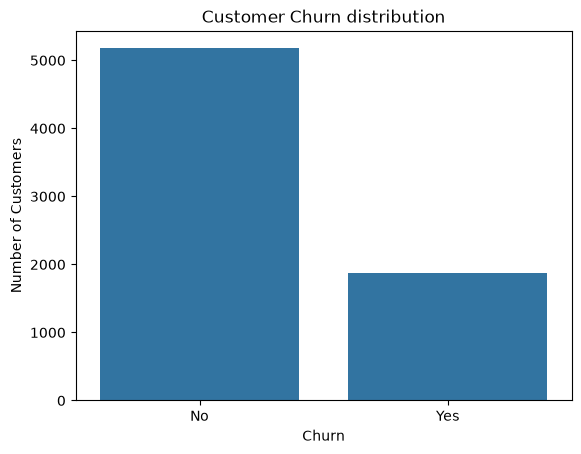

In [11]:
sns.countplot(data=df,x="Churn")

plt.title("Customer Churn distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()


## Unique Values Check

In [12]:
df["gender"].unique()

<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

In [13]:
for columns in df.select_dtypes(include="object").columns:
    print(f"\n{columns}:")
    print(df[columns].unique())


customerID:
<ArrowStringArray>
['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', '7795-CFOCW', '9237-HQITU',
 '9305-CDSKC', '1452-KIOVK', '6713-OKOMC', '7892-POOKP', '6388-TABGU',
 ...
 '9767-FFLEM', '0639-TSIQW', '8456-QDAVC', '7750-EYXWZ', '2569-WGERO',
 '6840-RESVB', '2234-XADUH', '4801-JZAZL', '8361-LTMKD', '3186-AJIEK']
Length: 7043, dtype: str

gender:
<ArrowStringArray>
['Female', 'Male']
Length: 2, dtype: str

Partner:
<ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str

Dependents:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

PhoneService:
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str

MultipleLines:
<ArrowStringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str

InternetService:
<ArrowStringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str

OnlineSecurity:
<ArrowStringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str

OnlineBackup:
<ArrowStringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str

DeviceProtecti

C:\Users\rathi\AppData\Local\Temp\ipykernel_27172\1059920235.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for columns in df.select_dtypes(include="object").columns:


In [14]:
df.select_dtypes(include="number").columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='str')

In [15]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [16]:
df["TotalCharges"].dtype

<StringDtype(na_value=nan)>

In [17]:
df["TotalCharges"].value_counts(dropna=False).tail()

TotalCharges
1990.5    1
7362.9    1
346.45    1
306.6     1
6844.5    1
Name: count, dtype: int64

In [18]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"],errors="coerce")

In [19]:
df["TotalCharges"].dtype

dtype('float64')

In [20]:
df["TotalCharges"].isnull().sum()

np.int64(11)

In [21]:
df[df["TotalCharges"].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [22]:
df = df.dropna(subset=["TotalCharges"])

In [23]:
df["TotalCharges"].isnull().sum()

np.int64(0)

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.dtypes

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                   str
dtype: object

In [26]:
df.shape

(7032, 21)

In [27]:
df =df.drop("customerID",axis=1)

In [28]:
df.shape

(7032, 20)

In [29]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [30]:
df["Churn"].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [31]:
df["Churn"].dtype

<StringDtype(na_value=nan)>

In [32]:
Categorical_columns=df.select_dtypes(include="object").columns 
Categorical_columns

C:\Users\rathi\AppData\Local\Temp\ipykernel_27172\1149770675.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  Categorical_columns=df.select_dtypes(include="object").columns


Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [33]:
Numerical_columns =df.select_dtypes(include="number").columns 
Numerical_columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

## List comprehension

In [34]:
binary_columns = [
    column for column in Categorical_columns
    if df[column].nunique() == 2
]

binary_columns

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'PaperlessBilling',
 'Churn']

## Encoding

In [35]:
yes_no_columns = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

for column in yes_no_columns:
    df[column] = df[column].map({"No":0,"Yes":1})

In [36]:
df["gender"] = df["gender"].map({"Female":0,"Male":1})

In [37]:
df[["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn"]].head()

,gender,Partner,Dependents,PhoneService,PaperlessBilling,Churn
0,0,1,0,0,1,0
1,1,0,0,1,0,0
2,1,0,0,1,1,1
3,1,0,0,0,0,0
4,0,0,0,1,1,1


## Multi columns

In [38]:
multi_category_columns = [
    column for column in Categorical_columns
    if df[column].nunique() > 2
]

multi_category_columns

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod']

In [39]:
df = pd.get_dummies(
    df,
    columns=multi_category_columns,
    drop_first=True,
    dtype=int
)

In [40]:
df.select_dtypes(include="object").columns

Index([], dtype='str')

In [41]:
df.isnull().sum().sum()

np.int64(0)

## EDA

In [42]:
df["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [43]:
df["Churn"].value_counts(normalize=True) * 100

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

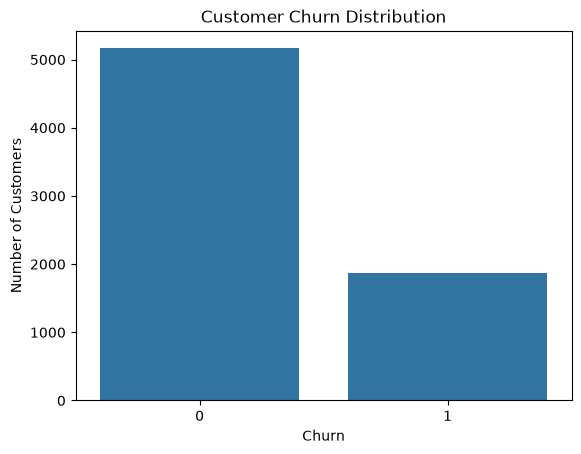

In [44]:
sns.countplot(data=df,x="Churn")

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

In [45]:
df.groupby("Churn")["tenure"].mean()

Churn
0    37.650010
1    17.979133
Name: tenure, dtype: float64

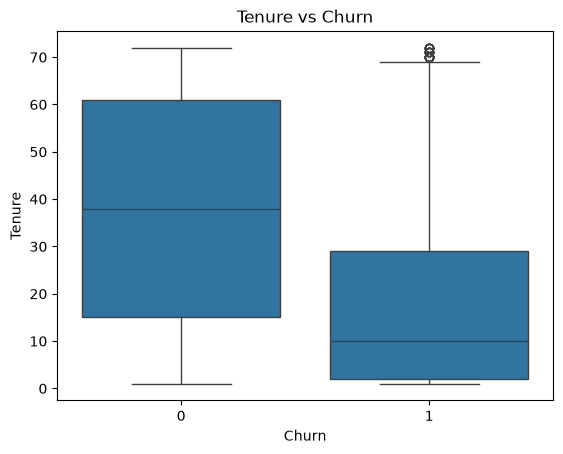

In [46]:
sns.boxplot(data=df,x="Churn",y="tenure")

plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure")

plt.show()

In [47]:
df.groupby("Churn")["MonthlyCharges"].mean()

Churn
0    61.307408
1    74.441332
Name: MonthlyCharges, dtype: float64

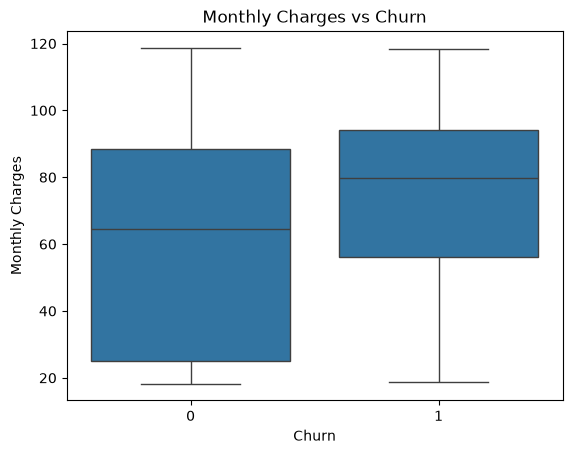

In [48]:
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [49]:
df[
    (df["Contract_One year"] == 0) &
    (df["Contract_Two year"] == 0)
]["Churn"].mean() * 100

np.float64(42.70967741935484)

In [50]:
df[df["Contract_One year"] == 1]["Churn"].mean() * 100

np.float64(11.277173913043478)

In [51]:
df[df["Contract_Two year"] == 1]["Churn"].mean() * 100

np.float64(2.8486646884272995)

In [52]:
df[["Contract_One year", "Contract_Two year"]].head()

,Contract_One year,Contract_Two year
0,0,0
1,1,0
2,0,0
3,1,0
4,0,0


In [53]:
import numpy as np

In [54]:
df["ContractType"] = np.select(
    [
        df["Contract_One year"] == 1,
        df["Contract_Two year"] == 1
    ],
    [
        "One year",
        "Two year"
    ],
    default="Month-to-month"
)

In [55]:
df["ContractType"].unique()

<ArrowStringArray>
['Month-to-month', 'One year', 'Two year']
Length: 3, dtype: str

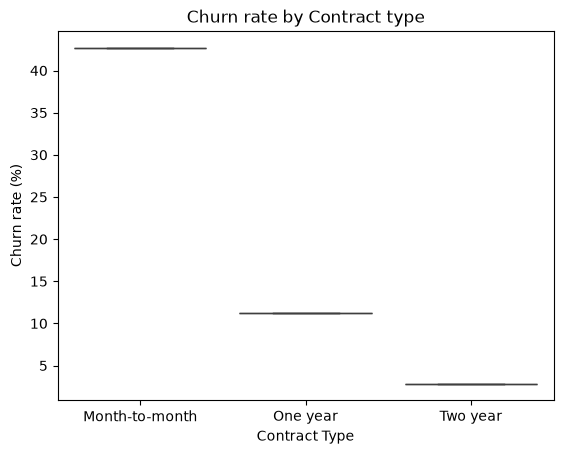

In [56]:
contract_churn = df.groupby("ContractType")["Churn"].mean() * 100

sns.boxplot(
    x=contract_churn.index,
    y=contract_churn.values    
)

plt.title("Churn rate by Contract type")
plt.xlabel("Contract Type")
plt.ylabel("Churn rate (%)")
plt.show()

In [57]:
df = df.drop("ContractType", axis=1)

### InternetService vs Churn 🌐

In [58]:
[ column for column in df.columns if "InternetService" in column]

['InternetService_Fiber optic', 'InternetService_No']

In [59]:
df[df["InternetService_Fiber optic"] == 1]["Churn"].mean() * 100

np.float64(41.89276485788114)

In [60]:
df[df["InternetService_No"] == 1]["Churn"].mean() * 100

np.float64(7.434210526315789)

In [61]:
df[
    (df["InternetService_Fiber optic"] == 0) &
    (df["InternetService_No"] == 0)
]["Churn"].mean() * 100

np.float64(18.998344370860927)

In [62]:
df["InternetServiceType"] = np.select(
    [
        df["InternetService_Fiber optic"] == 1,
        df["InternetService_No"] ==1
    ],
    [
        "Fiber Optic",
        "No internet"
    ],
    default="DSL"
)

In [63]:
internet_churn = df.groupby("InternetServiceType")["Churn"].mean() * 100

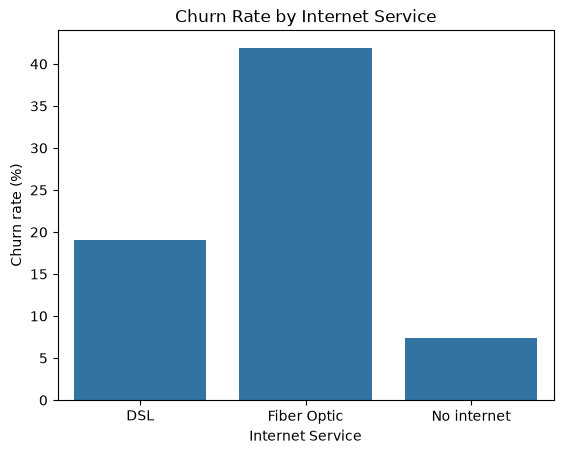

In [64]:
sns.barplot(
    x=internet_churn.index,
    y=internet_churn.values
)

plt.title("Churn Rate by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Churn rate (%)")

plt.show()

In [65]:
df = df.drop("InternetServiceType", axis=1)

### Payment Method vs Churn 💳

In [66]:
[column for column in df.columns if "PaymentMethod" in column]

['PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [67]:
df[df["PaymentMethod_Credit card (automatic)"] == 1]["Churn"].mean() * 100

np.float64(15.253122945430638)

In [68]:
df[df["PaymentMethod_Electronic check"] == 1]["Churn"].mean() * 100

np.float64(45.28541226215645)

In [69]:
df[df["PaymentMethod_Mailed check"] == 1]["Churn"].mean() * 100

np.float64(19.201995012468828)

In [70]:
df[
    (df["PaymentMethod_Credit card (automatic)"] == 0)&
    (df["PaymentMethod_Electronic check"] == 0)&
    (df["PaymentMethod_Mailed check"] == 0)
]["Churn"].mean() * 100

np.float64(16.731517509727624)

In [71]:
df["PaymentMethodType"] = np.select(
    [
        df["PaymentMethod_Credit card (automatic)"] == 1,
        df["PaymentMethod_Electronic check"] == 1,
        df["PaymentMethod_Mailed check"] == 1
    ],
    [
        "Credit card",
        "Electronic check",
        "Mailed check"
    ],
    default="Bank transfer"
)

In [72]:
payment_churn = df.groupby("PaymentMethodType")["Churn"].mean() * 100
payment_churn

PaymentMethodType
Bank transfer       16.731518
Credit card         15.253123
Electronic check    45.285412
Mailed check        19.201995
Name: Churn, dtype: float64

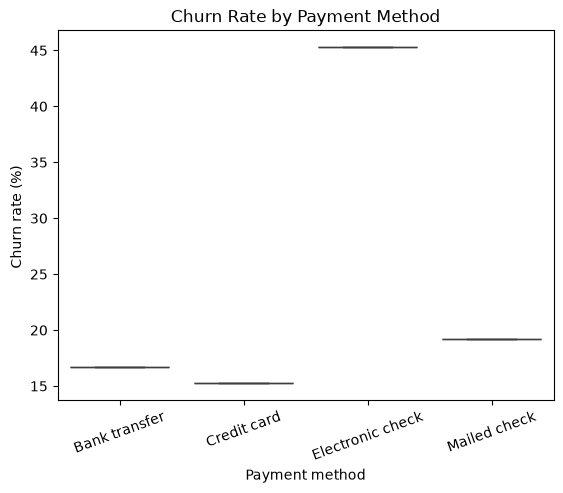

In [73]:
sns.boxplot(
    x=payment_churn.index,
    y=payment_churn.values
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment method")
plt.ylabel("Churn rate (%) ")
plt.xticks(rotation=20)
plt.show()

In [74]:
df = df.drop("PaymentMethodType", axis=1)

In [75]:
senior_churn = df.groupby("SeniorCitizen")["Churn"].mean() * 100
senior_churn

SeniorCitizen
0    23.650255
1    41.681261
Name: Churn, dtype: float64

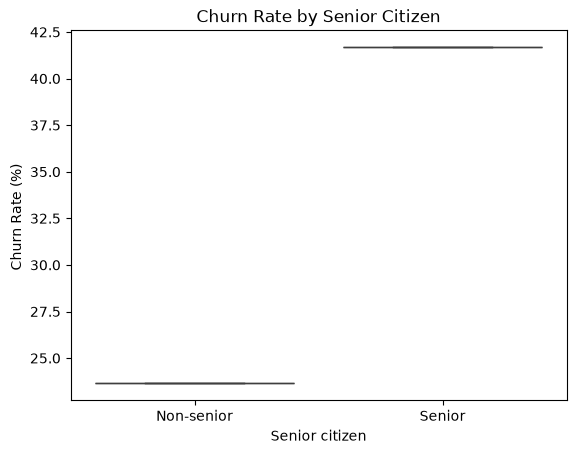

In [76]:
sns.boxplot(
    x=senior_churn.index,
    y=senior_churn.values
)

plt.title("Churn Rate by Senior Citizen")
plt.xlabel("Senior citizen")
plt.ylabel("Churn Rate (%) ")
plt.xticks([0,1],["Non-senior","Senior"])
plt.show()

### OnlineSecurity vs Churn

In [77]:
[column for column in df.columns if "OnlineSecurity" in column]

['OnlineSecurity_No internet service', 'OnlineSecurity_Yes']

In [78]:
df["OnlineSecurityType"] = np.select(
    [
        df["OnlineSecurity_Yes"] == 1 ,
        df["OnlineSecurity_No internet service"] == 1
    ],
    [
        "Yes",
        "No internet service"
    ],
    default="No"
)

In [79]:
onlinesecurity_churn = df.groupby("OnlineSecurityType")["Churn"].mean() * 100
onlinesecurity_churn

OnlineSecurityType
No                     41.778667
No internet service     7.434211
Yes                    14.640199
Name: Churn, dtype: float64

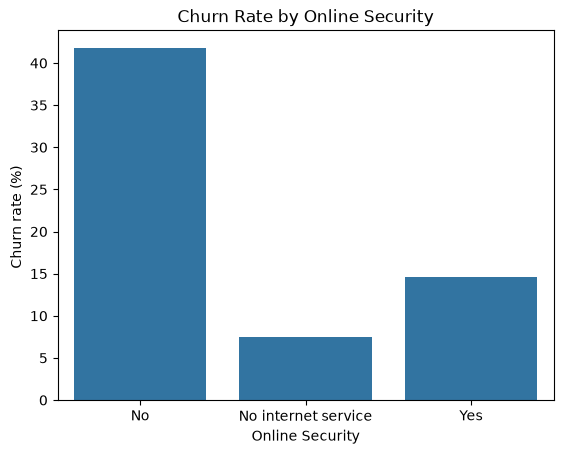

In [80]:
sns.barplot(
    x=onlinesecurity_churn.index,
    y=onlinesecurity_churn.values
)

plt.title("Churn Rate by Online Security")
plt.xlabel("Online Security")
plt.ylabel("Churn rate (%) ")
plt.show()

In [81]:
df = df.drop( "OnlineSecurityType"  ,axis=1)

### OnlineBackup vs Churn

In [82]:
[column for column in df.columns if "OnlineBackup" in column]

['OnlineBackup_No internet service', 'OnlineBackup_Yes']

In [83]:
df["OnlineBackupType"] = np.select(
    [
        df["OnlineBackup_Yes"] == 1,
        df["OnlineBackup_No internet service"] == 1
    ],
    [
        "Yes",
        "No internet service"
    ],
    default="No"
)

In [84]:
onlinebackup_churn = df.groupby("OnlineBackupType")["Churn"].mean() * 100
onlinebackup_churn

OnlineBackupType
No                     39.941691
No internet service     7.434211
Yes                    21.567010
Name: Churn, dtype: float64

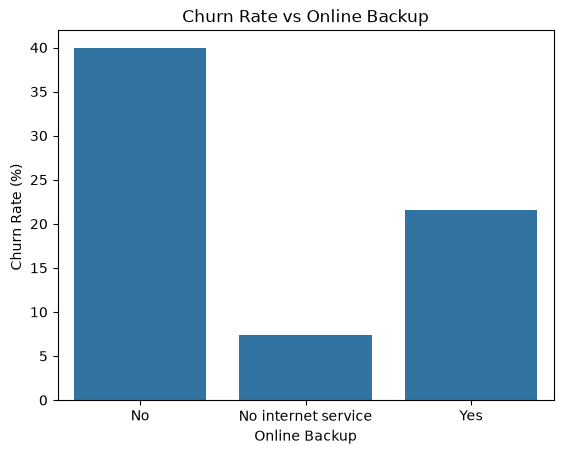

In [85]:
sns.barplot(
    x=onlinebackup_churn.index,
    y=onlinebackup_churn.values
)

plt.title("Churn Rate vs Online Backup")
plt.xlabel("Online Backup")
plt.ylabel("Churn Rate (%) ")
plt.show()

In [86]:
df = df.drop("OnlineBackupType",axis=1)

### Tech Support vs Churn

In [87]:
[column for column in df.columns  if "TechSupport" in column]

['TechSupport_No internet service', 'TechSupport_Yes']

In [88]:
df["TechSupportType"] = np.select(
    [
        df["TechSupport_Yes"] == 1,
        df["TechSupport_No internet service"] == 1
    ],
    [
        "Yes",
        "No internet service"
    ],
    default="No"
)

In [89]:
techsupport_churn = df.groupby("TechSupportType")["Churn"].mean() * 100
techsupport_churn

TechSupportType
No                     41.647465
No internet service     7.434211
Yes                    15.196078
Name: Churn, dtype: float64

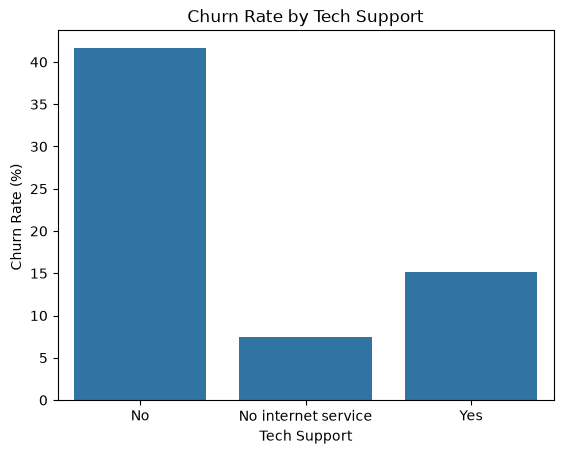

In [90]:
sns.barplot(
    x=techsupport_churn.index,
    y=techsupport_churn.values
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%) ")
plt.show()

In [91]:
df = df.drop("TechSupportType",axis=1)

### Device Protection vs Churn

In [92]:
[column for column in df.columns if "DeviceProtection" in column]

['DeviceProtection_No internet service', 'DeviceProtection_Yes']

In [93]:
df["DeviceProtectionType"] = np.select(
    [
        df["DeviceProtection_Yes"] == 1,
        df["DeviceProtection_No internet service"] == 1
    ],
    [
        "Yes",
        "No internet service"
    ],
    default="No"
)

In [94]:
deviceprotection_churn = df.groupby("DeviceProtectionType")["Churn"].mean() * 100
deviceprotection_churn

DeviceProtectionType
No                     39.140271
No internet service     7.434211
Yes                    22.539289
Name: Churn, dtype: float64

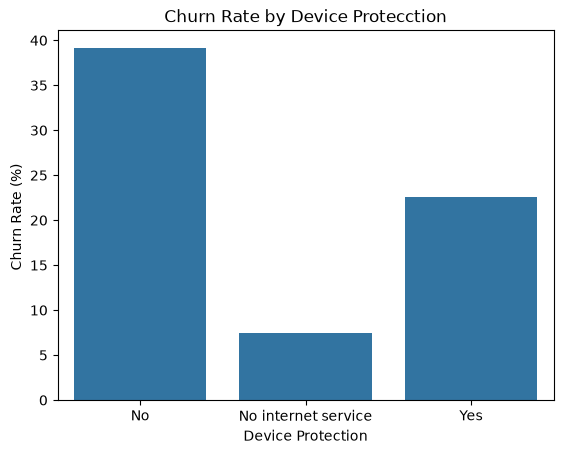

In [95]:
sns.barplot(
    x=deviceprotection_churn.index,
    y=deviceprotection_churn.values
)

plt.title("Churn Rate by Device Protecction")
plt.xlabel("Device Protection")
plt.ylabel("Churn Rate (%) ")
plt.show()

In [96]:
df = df.drop("DeviceProtectionType", axis=1)

## Feature Engineering

In [97]:
X = df.drop("Churn" , axis=1)
Y = df["Churn"]

In [98]:
X.shape
Y.shape

(7032,)

In [99]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [100]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (5625, 30)
X_test : (1407, 30)
y_train: (5625,)
y_test : (1407,)


### Traning

In [101]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

c:\Users\rathi\OneDrive\Desktop\project\Customer-Churn-Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

### Testing


In [102]:
y_pred = model.predict(X_test)

In [103]:
y_pred[:10]

array([0, 1, 0, 0, 0, 0, 0, 0, 1, 0])

### Model evaluation

### Accuracy

In [104]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test,y_pred)
 
print("Accuracy:",accuracy)

Accuracy: 0.8031272210376688


### Confusion matrix

In [105]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,y_pred)

print(cm)

[[915 118]
 [159 215]]


### Classification report

In [106]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [107]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.8364234279472591


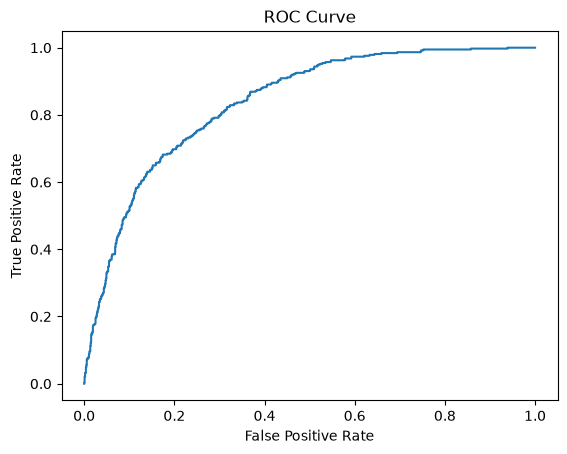

In [108]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr,tpr,thresholds = roc_curve(y_test,y_prob)

plt.plot(fpr,tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

### Churn Recall improvement

In [109]:
model_balanced = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

In [110]:
model_balanced.fit(X_train,y_train)

c:\Users\rathi\OneDrive\Desktop\project\Customer-Churn-Prediction\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [111]:
y_pred_balanced = model_balanced.predict(X_test)

In [112]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred_balanced))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



In [113]:
y_prob_balanced =  model_balanced.predict_proba(X_test)[:,1]

auc_balanced = roc_auc_score(y_test,y_prob_balanced)

print("ROC_AUC :",auc_balanced)
 

ROC_AUC : 0.8360222290095305


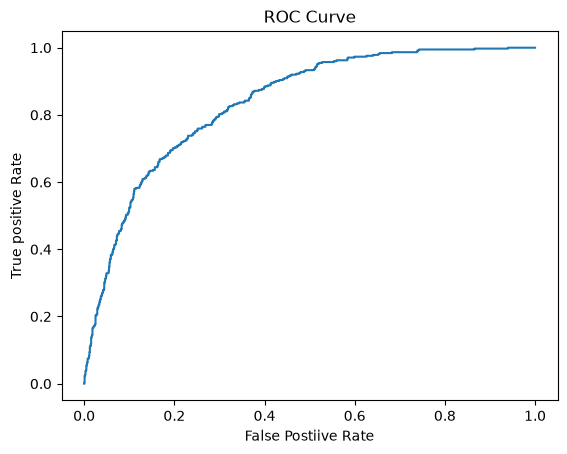

In [114]:
fpr,tpr,thresholds = roc_curve(y_test,y_prob_balanced)

plt.plot(fpr,tpr)
plt.title("ROC Curve")
plt.xlabel("False Postiive Rate")
plt.ylabel("True positive Rate")
plt.show()

### Model Improvement


### Feature Scaling

In [115]:
from sklearn.preprocessing import StandardScaler

In [116]:
scaler =StandardScaler()

In [117]:
X_train_scaled = scaler.fit_transform(X_train)

In [118]:
X_test_scaled = scaler.transform(X_test)

### New model

In [119]:
model_scaled = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

In [120]:
model_scaled.fit(X_train_scaled,y_train)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to

In [121]:
y_pred_scaled = model_scaled.predict(X_test_scaled)

In [122]:
print(classification_report(y_test,y_pred_scaled))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [123]:
y_prob_scaled = model_scaled.predict_proba(X_test_scaled)[:,1]

auc_scaled = roc_auc_score(y_test,y_prob_scaled)

print("ROC_AUC :",auc_scaled)

ROC_AUC : 0.8349765233911922


## Random Forest Algorithm

In [124]:
from sklearn.ensemble import RandomForestClassifier

In [125]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

In [126]:
rf_model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [127]:
y_pred_rf = rf_model.predict(X_test)

In [128]:
print(classification_report(y_test,y_pred_rf))

              precision    recall  f1-score   support

           0       0.86      0.81      0.84      1033
           1       0.56      0.65      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.77      0.77      1407



In [129]:
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

rf_auc = roc_auc_score(y_test,y_prob_rf)\
    
print("ROC-AUC :",rf_auc)

ROC-AUC : 0.8200881602310907


##  Gradient Boosting Algorithm

In [130]:
from sklearn.ensemble import GradientBoostingClassifier

In [131]:
gb_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

In [132]:
gb_model.fit(X_train,y_train)

,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (i

In [133]:
y_pred_gb = gb_model.predict(X_test)

In [134]:
print(classification_report(y_test,y_pred_gb))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1033
           1       0.64      0.53      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



In [135]:
y_prob_gb = gb_model.predict_proba(X_test)[:, 1]

auc_gb = roc_auc_score(y_test, y_prob_gb)

print("Gradient Boosting ROC-AUC:", auc_gb)

Gradient Boosting ROC-AUC: 0.8406554296452367


### Model Comparison

In [136]:
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Balanced Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.73,
        0.77,
        0.80
    ],
    "Churn Recall": [
        0.80,
        0.65,
        0.53
    ],
    "Churn F1": [
        0.61,
        0.60,
        0.58
    ],
    "ROC-AUC": [
        0.8350,
        0.8201,
        0.8407
    ]
})

model_comparison

,Model,Accuracy,Churn Recall,Churn F1,ROC-AUC
0,Balanced Logistic Regression,0.73,0.80,0.61,0.8350
1,Random Forest,0.77,0.65,0.60,0.8201
2,Gradient Boosting,0.80,0.53,0.58,0.8407


### Hyperparameter Tuning

In [137]:
from sklearn.model_selection import GridSearchCV

In [138]:
param_grid = {
    "C": [0.01, 0.1, 1, 10, 100]
}

In [139]:
log_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

In [140]:
grid_search = GridSearchCV(
    estimator=log_model,
    param_grid=param_grid,
    cv=5,
    scoring="recall",
    n_jobs=-1
)

In [141]:
grid_search.fit(X_train_scaled,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",LogisticRegre...max_iter=1000)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with high

In [142]:
print("Best C:", grid_search.best_params_)

Best C: {'C': 1}


In [143]:
print("Best CV Recall:",grid_search.best_score_)

Best CV Recall: 0.8033444816053512


### Best_model

In [144]:
best_model = grid_search.best_estimator_

In [145]:
y_pred_tuned = grid_search.predict(X_test_scaled)

In [146]:
print(classification_report(y_test,y_pred_tuned))

              precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.74      1407



In [147]:
y_prob_tuned = best_model.predict_proba(X_test_scaled)[:, 1]

auc_tuned = roc_auc_score(y_test, y_prob_tuned)

print("Tuned Logistic Regression ROC-AUC:", auc_tuned)

Tuned Logistic Regression ROC-AUC: 0.8349765233911922


In [148]:
final_comparison = pd.DataFrame({
    "Model": [
        "Balanced Logistic Regression",
        "Tuned Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.73,
        0.73,
        0.77,
        0.80
    ],
    "Churn Recall": [
        0.80,
        0.80,
        0.65,
        0.53
    ],
    "Churn F1": [
        0.61,
        0.61,
        0.60,
        0.58
    ],
    "ROC-AUC": [
        0.8350,
        0.8350,
        0.8201,
        0.8407
    ]
})

final_comparison

,Model,Accuracy,Churn Recall,Churn F1,ROC-AUC
0,Balanced Logistic Regression,0.73,0.80,0.61,0.8350
1,Tuned Logistic Regression,0.73,0.80,0.61,0.8350
2,Random Forest,0.77,0.65,0.60,0.8201
3,Gradient Boosting,0.80,0.53,0.58,0.8407


In [149]:
final_model = best_model

### Save model

In [150]:
import joblib

In [151]:
joblib.dump(final_model,"../Models/churn_model.pkl")

['../Models/churn_model.pkl']

In [152]:
joblib.dump(scaler,"../Models/Scaler.pkl")

['../Models/Scaler.pkl']

In [153]:
print(os.path.exists("../Models/churn_model.pkl"))
print(os.path.exists("../Models/scaler.pkl"))

True
True
